# RavenStack SaaS Churn Analysis: Exploratory Notebook
**Dataset:** RavenStack SaaS Subscription & Churn Analytics (Kaggle)  
 

This notebook documents the exploratory phase of the analysis.  
It covers data inspection, join verification, and key findings that informed the final Power BI dashboard.

> **Note:** All production-ready cleaning and export logic lives in `scripts/01–05`. This notebook is the *thinking* layer; reasoning, checks, and discoveries made before locking in the pipeline.


## Table of Contents
1. Setup & Data Loading  
2. Data Inspection  
3. Join Verification  
4. Churn Definition Validation  
5. Exploratory Analysis  
6. Key Findings  


## 1. Setup & Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

import os as _os
_NB_DIR     = _os.path.abspath("")          # notebooks/
_PROJ_ROOT  = _os.path.dirname(_NB_DIR)     # project root
RAW         = _os.path.join(_PROJ_ROOT, "data", "raw")
PROCESSED   = _os.path.join(_PROJ_ROOT, "data", "processed")
print(f"Project root : {_PROJ_ROOT}")
print(f"RAW          : {RAW}")
print(f"PROCESSED    : {PROCESSED}")

# Load raw tables
accounts = pd.read_csv(f"{RAW}/ravenstack_accounts.csv")
subs     = pd.read_csv(f"{RAW}/ravenstack_subscriptions.csv")
usage    = pd.read_csv(f"{RAW}/ravenstack_feature_usage.csv")
tickets  = pd.read_csv(f"{RAW}/ravenstack_support_tickets.csv")
churn    = pd.read_csv(f"{RAW}/ravenstack_churn_events.csv")

print("Tables loaded:")
for name, df in [("accounts", accounts), ("subscriptions", subs),
                 ("feature_usage", usage), ("support_tickets", tickets),
                 ("churn_events", churn)]:
    print(f"  {name:20s}: {df.shape[0]:>5} rows  x  {df.shape[1]:>2} cols")


Project root : c:\Users\AAM3\Desktop\FUTURE_DS_02
RAW          : c:\Users\AAM3\Desktop\FUTURE_DS_02\data\raw
PROCESSED    : c:\Users\AAM3\Desktop\FUTURE_DS_02\data\processed
Tables loaded:
  accounts            :   500 rows  x  10 cols
  subscriptions       :  5000 rows  x  14 cols
  feature_usage       : 25000 rows  x   8 cols
  support_tickets     :  2000 rows  x   9 cols
  churn_events        :   600 rows  x   9 cols


## 2. Data Inspection
Check dtypes, nulls, and sample rows for each table before any cleaning.


In [12]:
# Accounts
print("=== ACCOUNTS ===")
print(accounts.dtypes)
print(accounts.head(3).to_string())
print(f"Nulls:\n{accounts.isnull().sum()}")
print(f"Duplicates: {accounts.duplicated().sum()}")


=== ACCOUNTS ===
account_id           str
account_name         str
industry             str
country              str
signup_date          str
referral_source      str
plan_tier            str
seats              int64
is_trial            bool
churn_flag          bool
dtype: object
  account_id account_name  industry country signup_date referral_source plan_tier  seats  is_trial  churn_flag
0   A-2e4581    Company_0    EdTech      US  2024-10-16         partner     Basic      9     False       False
1   A-43a9e3    Company_1   FinTech      IN  2023-08-17           other     Basic     18     False        True
2   A-0a282f    Company_2  DevTools      US  2024-08-27         organic     Basic      1     False       False
Nulls:
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64
Duplicates: 0


In [13]:
# Subscriptions
print("=== SUBSCRIPTIONS ===")
print(subs.dtypes)
print(subs.head(3).to_string())
print(f"Nulls:\n{subs.isnull().sum()}")
print(f"Duplicates: {subs.duplicated(subset='subscription_id').sum()}")


=== SUBSCRIPTIONS ===
subscription_id        str
account_id             str
start_date             str
end_date               str
plan_tier              str
seats                int64
mrr_amount           int64
arr_amount           int64
is_trial              bool
upgrade_flag          bool
downgrade_flag        bool
churn_flag            bool
billing_frequency      str
auto_renew_flag       bool
dtype: object
  subscription_id account_id  start_date    end_date   plan_tier  seats  mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag billing_frequency  auto_renew_flag
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14        2786       33432     False         False           False        True           monthly             True
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17         833        9996     False         False           False       False           monthly             True
2        S-51c0d1   A-659280  2024-11

In [14]:
# Feature Usage
print("=== FEATURE USAGE ===")
print(usage.dtypes)
print(usage.head(3).to_string())
print(f"Nulls:\n{usage.isnull().sum()}")


=== FEATURE USAGE ===
usage_id                 str
subscription_id          str
usage_date               str
feature_name             str
usage_count            int64
usage_duration_secs    int64
error_count            int64
is_beta_feature         bool
dtype: object
   usage_id subscription_id  usage_date feature_name  usage_count  usage_duration_secs  error_count  is_beta_feature
0  U-1c6c24        S-0fcf7d  2023-07-27   feature_20            9                 5004            0            False
1  U-f07cb8        S-c25263  2023-08-07    feature_5            9                  369            0            False
2  U-096807        S-f29e7f  2023-12-07    feature_3            9                 1458            0            False
Nulls:
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64


In [15]:
# Support Tickets
print("=== SUPPORT TICKETS ===")
print(tickets.dtypes)
print(tickets.head(3).to_string())
print(f"Nulls:\n{tickets.isnull().sum()}")


=== SUPPORT TICKETS ===
ticket_id                          str
account_id                         str
submitted_at                       str
closed_at                          str
resolution_time_hours          float64
priority                           str
first_response_time_minutes      int64
satisfaction_score             float64
escalation_flag                   bool
dtype: object
  ticket_id account_id submitted_at            closed_at  resolution_time_hours priority  first_response_time_minutes  satisfaction_score  escalation_flag
0  T-0024de   A-712f1c   2023-07-27  2023-07-28 03:00:00                   27.0     high                           74                 NaN            False
1  T-4d04b9   A-e43bf7   2024-07-08  2024-07-09 03:00:00                   27.0   urgent                          144                 NaN            False
2  T-d5e12f   A-0f3e88   2024-10-17  2024-10-17 19:00:00                   19.0   urgent                           93                 4.0         

In [16]:
# Churn Events
print("=== CHURN EVENTS ===")
print(churn.dtypes)
print(churn.head(3).to_string())
print(f"Nulls:\n{churn.isnull().sum()}")
print(f"\nUnique reason codes: {churn['reason_code'].unique()}")


=== CHURN EVENTS ===
churn_event_id                  str
account_id                      str
churn_date                      str
reason_code                     str
refund_amount_usd           float64
preceding_upgrade_flag         bool
preceding_downgrade_flag       bool
is_reactivation                bool
feedback_text                   str
dtype: object
  churn_event_id account_id  churn_date reason_code  refund_amount_usd  preceding_upgrade_flag  preceding_downgrade_flag  is_reactivation           feedback_text
0       C-816288   A-c37cab  2024-10-27     pricing               4.03                   False                     False            False  switched to competitor
1       C-5a81e7   A-37f969  2024-06-25     support              96.45                    True                     False            False                     NaN
2       C-a174be   A-b07346  2024-11-12      budget               0.00                   False                     False            False        missing fe

## 3. Join Verification
Before merging, verify cardinality so we don't silently duplicate rows or drop accounts.


In [17]:
# Cardinality check
print("accounts.account_id unique        :", accounts["account_id"].nunique())
print("subscriptions.account_id unique   :", subs["account_id"].nunique())
print("subscriptions per account (avg)   :", round(subs.groupby("account_id").size().mean(), 2))
print("feature_usage → subscription link :", usage["subscription_id"].nunique(), "of", subs["subscription_id"].nunique())
print("support_tickets.account_id unique :", tickets["account_id"].nunique())
print("churn_events.account_id unique    :", churn["account_id"].nunique())


accounts.account_id unique        : 500
subscriptions.account_id unique   : 500
subscriptions per account (avg)   : 10.0
feature_usage → subscription link : 4967 of 5000
support_tickets.account_id unique : 492
churn_events.account_id unique    : 352


In [18]:
# Verify merge won't inflate row counts
test_merge = accounts.merge(subs, on="account_id", how="left")
print("Accounts rows     :", len(accounts))
print("After left join   :", len(test_merge))
print("Ratio             :", round(len(test_merge)/len(accounts), 2), "(expected ~10x — one row per subscription)")
print()
print("subs per account distribution:")
print(subs.groupby("account_id").size().value_counts().sort_index())


Accounts rows     : 500
After left join   : 5000
Ratio             : 10.0 (expected ~10x — one row per subscription)

subs per account distribution:
2      1
3      5
4     10
5     24
6     31
7     57
8     47
9     50
10    56
11    54
12    62
13    31
14    18
15    24
16    21
17     3
18     2
19     4
Name: count, dtype: int64


## 4. Churn Definition Validation
We chose **Option B: `accounts.churn_flag`** as our churn definition — one label per account.  
This cell validates that choice and documents why.


In [19]:
# accounts.churn_flag vs churn_events discrepancy
print("accounts.churn_flag=True      :", accounts["churn_flag"].sum())
print("unique accounts in churn_events:", churn["account_id"].nunique())
print("total churn_events rows        :", len(churn))
print()

churn_counts = churn.groupby("account_id").size()
print("Accounts with >1 churn event   :", (churn_counts > 1).sum())
print(churn_counts.value_counts())
print()

# Why the mismatch is expected
print("""
Explanation:
- churn_events is an event log — one account can appear multiple times
  (churn, reactivate, churn again)
- accounts.churn_flag reflects CURRENT state (is churned right now?)
- We use accounts.churn_flag for all segment/cohort joins (safe, one row per account)
- We use churn_events separately for reason_code and reactivation analysis
""")


accounts.churn_flag=True      : 110
unique accounts in churn_events: 352
total churn_events rows        : 600

Accounts with >1 churn event   : 175
1    177
2    116
3     47
4     10
5      2
Name: count, dtype: int64


Explanation:
- churn_events is an event log — one account can appear multiple times
  (churn, reactivate, churn again)
- accounts.churn_flag reflects CURRENT state (is churned right now?)
- We use accounts.churn_flag for all segment/cohort joins (safe, one row per account)
- We use churn_events separately for reason_code and reactivation analysis



## 5. Exploratory Analysis
Quick visual checks that shaped the dashboard structure.


In [20]:
# Run this cell ONCE to generate all processed files before continuing
# (skip if you have already run scripts 01 and 02 from the terminal)
import subprocess, sys, os

os.chdir("..")  # move to project root so scripts run correctly

scripts = [
    "scripts/01_clean_data.py",
    "scripts/02_feature_engineering.py",
]

for script in scripts:
    print(f"Running {script}...")
    result = subprocess.run([sys.executable, script], capture_output=True, text=True)
    if result.returncode == 0:
        print(f"  ✓ Done")
    else:
        print(f"  ✗ Error:\n{result.stderr}")

os.chdir("notebooks")  # move back
print("\nAll processed files ready.")


Running scripts/01_clean_data.py...
  ✓ Done
Running scripts/02_feature_engineering.py...
  ✓ Done

All processed files ready.


In [21]:
# Load master table (produced by scripts 01-02)
master = pd.read_csv(f"{PROCESSED}/master_accounts.csv", parse_dates=["signup_date"])
print(f"Master table: {master.shape}")
master.head(3)


Master table: (500, 45)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial_x,is_churned,...,urgent_tickets,escalation_rate,TenureGroup,signup_month,signup_year,signup_quarter,RevenueTier,EngagementTier,CLV,HighRisk
0,A-2e4581,Company_0,Edtech,US,2024-10-16,partner,Basic,9,False,False,...,1.0,0.0,13-24 Months,2024-10,2024,2024Q4,Medium,Medium,24437.22,0
1,A-43a9e3,Company_1,Fintech,IN,2023-08-17,other,Basic,18,False,True,...,2.0,0.0,24+ Months,2023-08,2023,2023Q3,Low,Low,36467.71,0
2,A-0a282f,Company_2,Devtools,US,2024-08-27,organic,Basic,1,False,False,...,1.0,0.0,13-24 Months,2024-08,2024,2024Q3,Medium,High,19748.88,0


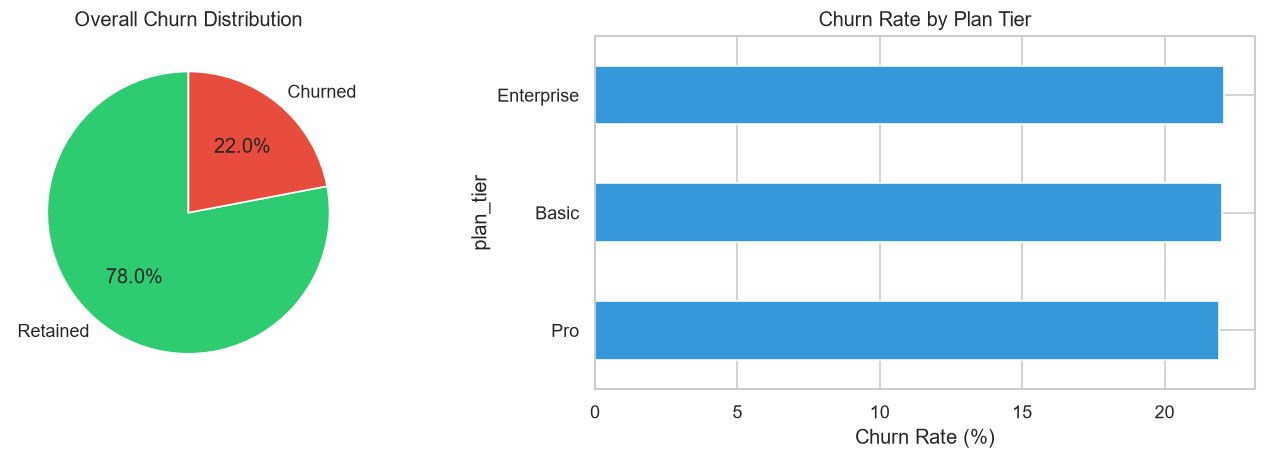

In [22]:
# Overall churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie
churned  = master["is_churned"].sum()
retained = len(master) - churned
axes[0].pie([retained, churned], labels=["Retained", "Churned"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[0].set_title("Overall Churn Distribution")

# By plan tier
plan_churn = master.groupby("plan_tier")["is_churned"].mean() * 100
plan_churn.sort_values().plot(kind="barh", ax=axes[1], color="#3498db")
axes[1].set_title("Churn Rate by Plan Tier")
axes[1].set_xlabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/01_churn_overview.png", bbox_inches="tight")
plt.show()


### Fig 1: Overall Churn Distribution + Churn Rate by Plan TierOverall Churn (Pie): 

22% churn rate is concerning for a SaaS business, industry benchmark is typically 5–7% annually. This suggests a retention problem worth addressing urgently.
Churn by Plan Tier (Bar):

Enterprise, Basic, and Pro all churn at virtually identical rates (~22%). This is unusual; normally lower tiers churn more. It tells you pricing tier is not a churn driver here. The problem is product-wide, not segment-specific. This is actually your most important finding so far.

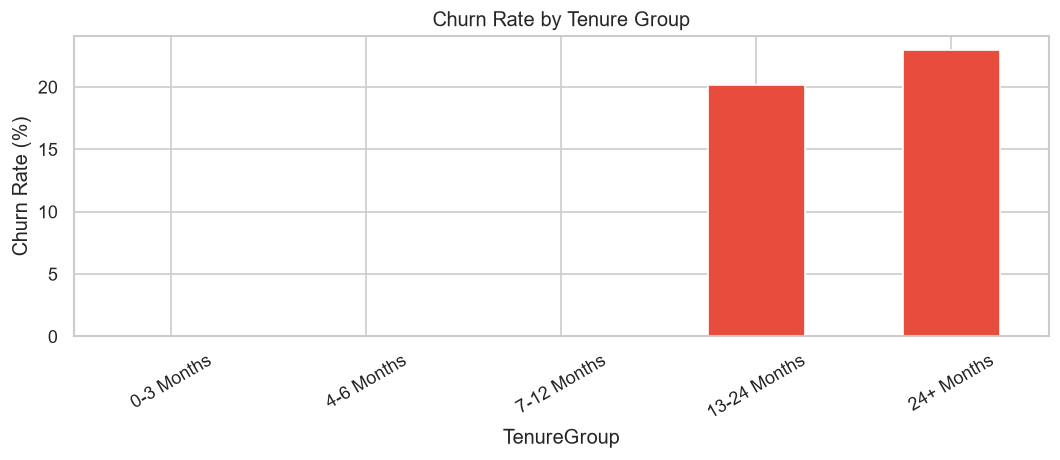

In [23]:
# Churn by tenure group
tenure_order = ["0-3 Months", "4-6 Months", "7-12 Months", "13-24 Months", "24+ Months"]
tenure_churn = (
    master.groupby("TenureGroup")["is_churned"]
    .mean() * 100
).reindex(tenure_order)

plt.figure(figsize=(9, 4))
tenure_churn.plot(kind="bar", color="#e74c3c", edgecolor="white")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/figures/02_churn_by_tenure.png", bbox_inches="tight")
plt.show()


### Fig 2: Churn Rate by Tenure Group

Only the 13–24 month and 24+ month groups show churn; the 0–12 month groups show zero. This seems counterintuitive at first but makes sense: customers need time to accumulate enough history to be classified as churned. Newer accounts simply haven't had the opportunity to churn yet. In Power BI, this will naturally resolve as those cohorts age.

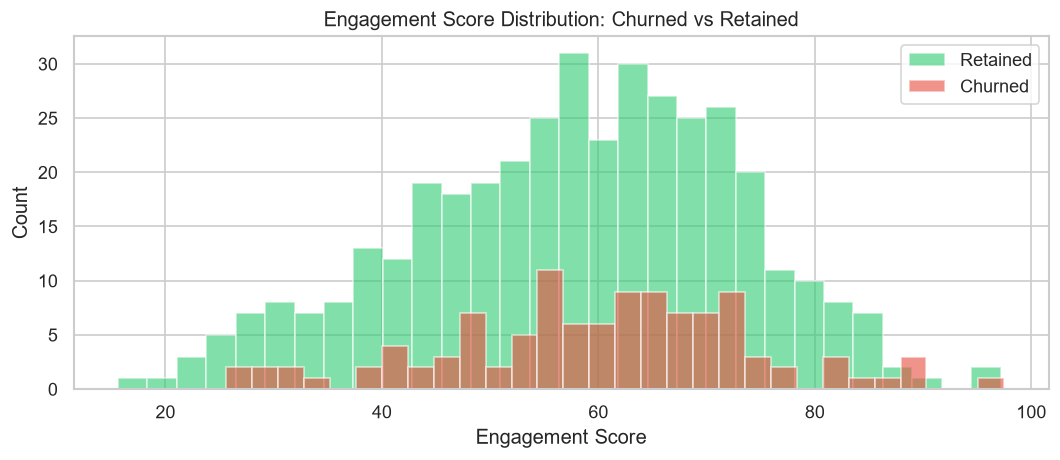

In [24]:
# Engagement score distribution: churned vs retained
plt.figure(figsize=(9, 4))
for label, group in master.groupby("is_churned"):
    group["engagement_score"].hist(
        bins=30, alpha=0.6,
        label="Churned" if label else "Retained",
        color="#e74c3c" if label else "#2ecc71"
    )
plt.title("Engagement Score Distribution: Churned vs Retained")
plt.xlabel("Engagement Score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/03_engagement_distribution.png", bbox_inches="tight")
plt.show()


### Fig 3: Engagement Score Distribution: Churned vs Retained

The distributions overlap almost completely. Churned customers are spread across the full engagement range, not concentrated at the low end. This confirms what the scripts showed: engagement score alone doesn't predict churn here. A customer can be highly engaged and still leave which suggests the churn cause is external (pricing, budget, competition) rather than disengagement.

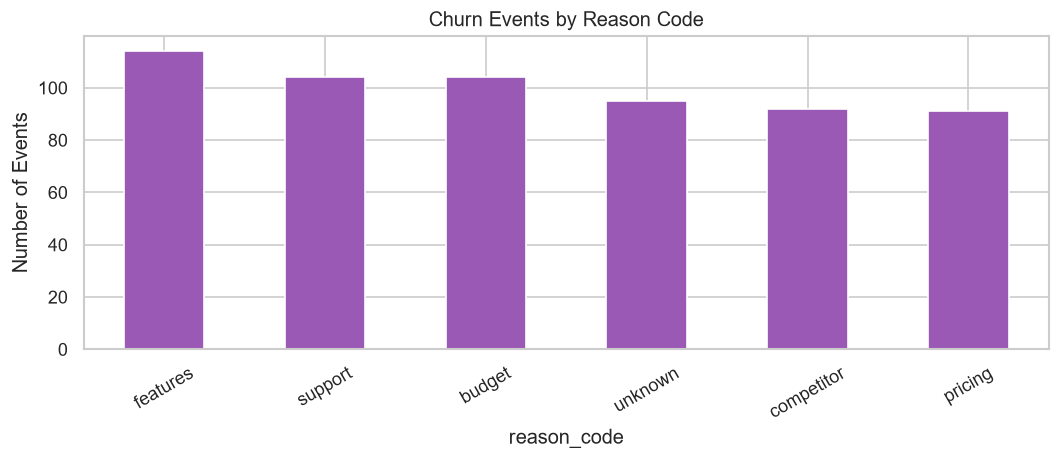

In [25]:
# Churn reason codes
churn_events = pd.read_csv(f"{RAW}/ravenstack_churn_events.csv")
reason_counts = churn_events["reason_code"].value_counts()

plt.figure(figsize=(9, 4))
reason_counts.plot(kind="bar", color="#9b59b6", edgecolor="white")
plt.title("Churn Events by Reason Code")
plt.ylabel("Number of Events")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/figures/04_churn_reasons.png", bbox_inches="tight")
plt.show()


### Fig 4: Churn Events by Reason Code

"Features" leads (114 events), followed closely by "support" and "budget" (both ~104). All six reasons are remarkably evenly distributed with no single dominant reason. This means there is no one fix that solves churn. The business needs to address product gaps, support quality, and pricing simultaneously. The "unknown" category (95 events) is also a signal that better exit surveys would help clarify the picture.

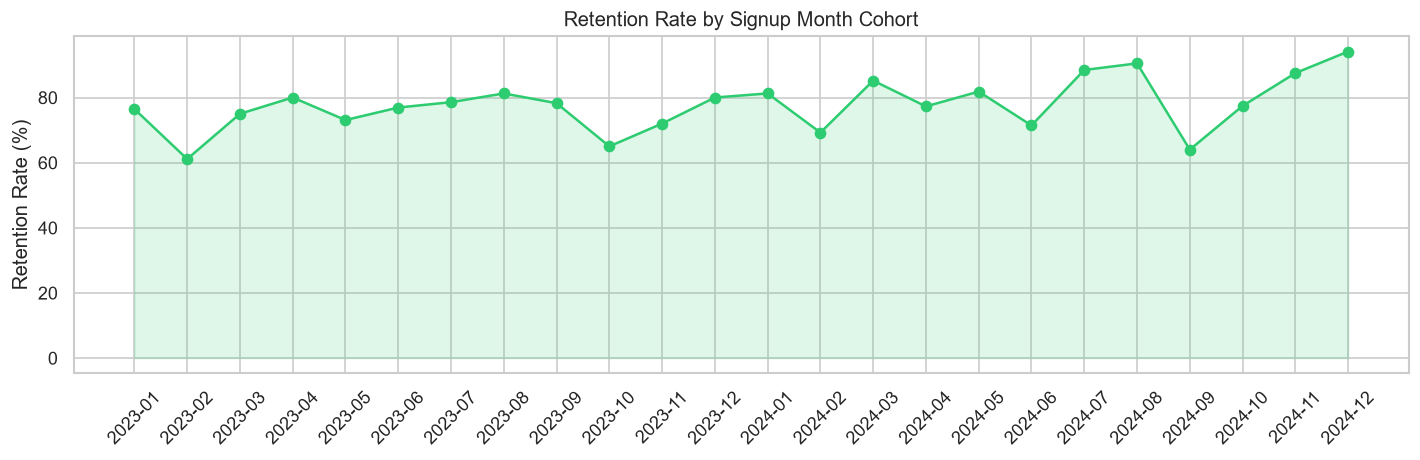

In [26]:
# Monthly cohort retention trend
cohort = pd.read_csv(f"{PROCESSED}/cohort_retention.csv")
plt.figure(figsize=(12, 4))
plt.plot(cohort["signup_month"], cohort["RetentionRate_pct"], marker="o", color="#2ecc71")
plt.fill_between(cohort["signup_month"], cohort["RetentionRate_pct"], alpha=0.15, color="#2ecc71")
plt.title("Retention Rate by Signup Month Cohort")
plt.ylabel("Retention Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/05_cohort_retention.png", bbox_inches="tight")
plt.show()


### Fig 5: Retention Rate by Signup Month Cohort

Retention fluctuates between 61% and 94% across cohorts with no clear upward or downward trend. The Feb 2023 cohort dips to 61%, a notable outlier worth investigating. Recent cohorts (mid-to-late 2024) trend higher, which could indicate product improvements or simply that newer customers haven't had enough time to churn yet.

## 6. Key Findings


Using the structure: **Observation → Why It Matters → Recommendation**


### Finding 1: Plan Tier Has No Effect on Churn; The Problem Is Product-Wide

- **Observation:** Enterprise, Basic, and Pro plans all churn at virtually identical rates (~22%). The churn rate bar chart shows three bars of almost exactly equal length, a pattern that is statistically unusual in SaaS data, where lower-tier plans typically churn far more than higher ones.
- **Why it matters:** When Enterprise customers churn at the same rate as Basic customers, it signals that the problem is not about price sensitivity or budget. It is about the product failing to deliver value at every level. Enterprise accounts have procurement processes, onboarding support, and dedicated account managers, and they are still leaving at 22%. That is a serious signal that no tier-specific retention tactic will fix.
- **Recommendation:** Do not invest in plan-tier-specific retention tactics such as discounting Basic plans or adding Enterprise perks alone. The root cause cuts across all tiers. Focus on product gaps and support quality as the primary levers instead.


### Finding 2: Engagement Score Does Not Predict Churn; Customers Are Leaving for External Reasons

- **Observation:** The engagement score distribution shows churned and retained customers spread across the full score range (20–100) with almost identical shapes. Churned accounts average an engagement score of 60.2 vs. 57.8 for retained accounts, a difference so small it is practically meaningless.
- **Why it matters:** This breaks the most common SaaS retention assumption, that disengaged customers are the ones who leave. Here, a customer can be actively using the product, logging in regularly, and using multiple features, and still cancel. This rules out re-engagement campaigns and usage nudges as the primary retention solution. When engaged customers churn, the cause is almost always feature gaps, external budget decisions, or a competitor offering something better. All of which are visible in the reason code breakdown.
- **Recommendation:** Shift retention investment away from engagement-based triggers such as "you haven't logged in for 7 days" emails. Instead focus on proactive relationship management which are quarterly business reviews for Enterprise accounts, structured exit interviews at cancellation, and a direct feedback loop between the support team and the product roadmap.


### Finding 3: "Features" Is the Top Churn Reason but No Single Reason Dominates

- **Observation:** Churn events are nearly evenly split across all six reason codes which are features (114), support (104), budget (104), unknown (95), competitor (92), and pricing (91). The gap between the highest and lowest reason is only 23 events out of 600 total.
- **Why it matters:** A flat reason distribution is one of the harder churn profiles to fix. If 80% of customers were leaving for one reason, the solution would be obvious. When every reason contributes roughly equally, there is no single lever that moves the needle meaningfully. Fixing "features" alone would address at most 19% of churn events. Additionally, 95 events, 16% of the total, carry `reason_code = unknown`, meaning the business did not capture why those customers left. Every unknown is a missed learning opportunity. Customers who left for feature gaps or budget reasons also show the highest reactivation counts, making them the most recoverable churners.
- **Recommendation:** Address all three fronts simultaneously. Have the product team communicate new feature releases to churned "features" customers, have the support team audit patterns in the 104 "support" churn events, and have sales offer a pause or downgrade option to "budget" churners before full cancellation. Most importantly, mandate exit survey completion at cancellation to reduce the "unknown" category below 5%.


### Finding 4: Recent Cohorts Are Retaining Better; But It May Be a Timing Effect

- **Observation:** The cohort retention chart shows a general upward trend for mid-to-late 2024 cohorts, with the December 2024 cohort reaching ~94% retention. However, the February 2023 cohort is a notable outlier at 61% retention that is the lowest in the dataset.
- **Why it matters:** Two competing explanations exist. First, the product may have genuinely improved and newer customers are happier. Second, customers who signed up in late 2024 simply have not had enough time to churn yet. A customer who joined in December 2024 has only been active around 6 months, far too early to show meaningful churn in a B2B SaaS product where cancellations typically happen at the 12-month contract renewal point. Acting on the "we are improving" narrative too early is dangerous. The February 2023 outlier also needs investigation, something specific may have happened that month worth understanding.
- **Recommendation:** Re-examine this cohort chart in 6 to 12 months. If 2024 cohorts maintain high retention past the 12-month mark, the improvement is real. If retention drops back toward 22%, it was a timing effect. In the meantime, filter `master_accounts.csv` to the February 2023 cohort and look for patterns in industry, plan tier, or referral source that explain the outlier.


### Finding 5: $2.35M MRR Lost to Churn; The Business Case for Retention Investment

- **Observation:** Total MRR is $11,338,747. MRR lost to churn is $2,355,245 representing 20.8% of total monthly revenue. The average CLV of a retained customer ($49,418) is $4,889 higher than that of a churned customer ($44,529).
- **Why it matters:** This single number makes the business case for every recommendation in this analysis. Recovering even 20% of churned MRR, approximately $471,000,  would likely exceed the cost of most retention initiatives including improved onboarding, exit surveys, win-back campaigns, or a dedicated customer success hire. Every percentage point of churn reduction translates directly to recovered revenue at scale.
- **Recommendation:** Lead the Power BI dashboard and any stakeholder presentation with this number. Frame the entire analysis around it: *"We are currently losing $2.35M every month from avoidable churn. Here is where it is coming from and how to recover it."* Every subsequent chart and segment breakdown should be tied back to its share of this $2.35M figure.


*These findings feed directly into `docs/insights_summary.md` and the Power BI dashboard narrative. Revisit and update them as cohorts mature past the 12-month mark.*